# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision

from os import path

from torch.utils.data import TensorDataset

from utils.plot import plot_digit_histograms

from scipy.ndimage import center_of_mass, shift

from sklearn.model_selection import StratifiedShuffleSplit

In [2]:
# Setting torch seed
random_seed = 1
torch.manual_seed(random_seed)

# Import fine tunning data

/mnt/fd5bc8a0-99f9-46e5-a3e6-cf0a9e8600dd/PULPIT/AGH_OPEN_DAYS/handwritten-digits-recognizer/venv/lib64/python3.11/site-packages/scipy/ndimage/_measurements.py:1550: RuntimeWarning: invalid value encountered in scalar divide
  results = [sum_labels(input * grids[dir].astype(float), labels, index) / normalizer


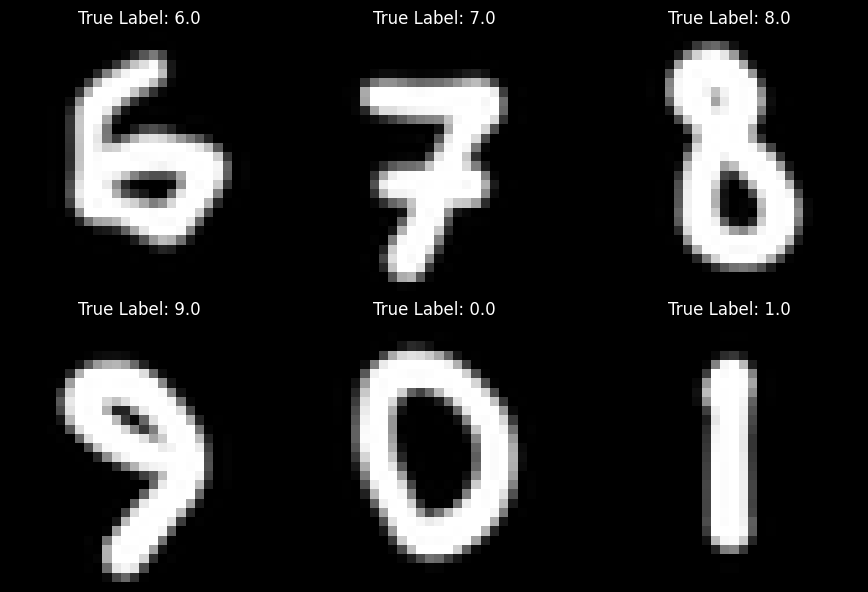

In [3]:
PATH = "fine-tuning-data-collector/fine_tune_data.csv"

line_data = np.genfromtxt(PATH, delimiter=',')

true_labels = np.array([d[0] for d in line_data], dtype=np.float32)
# Reshape, normalize in one line
data = np.array([(np.array(d[1:], dtype=np.float32) / 255.0).reshape((28, 28)) for d in line_data])

# Center image
centered_images = []
for img in data:
    if img.sum() < 1e-5:
        centered_images.append(img)
        continue

    c_y, c_x = center_of_mass(img)

    shift_x = 13.5 - c_x
    shift_y = 13.5 - c_y

    centered_image = shift(img, shift=(shift_y, shift_x), cval=0.0)
    centered_images.append(centered_image)

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.imshow(centered_images[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"True Label: {true_labels[i]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("six_images_subplots.png")

# Dara Preparation

## Splitting and shuffling data

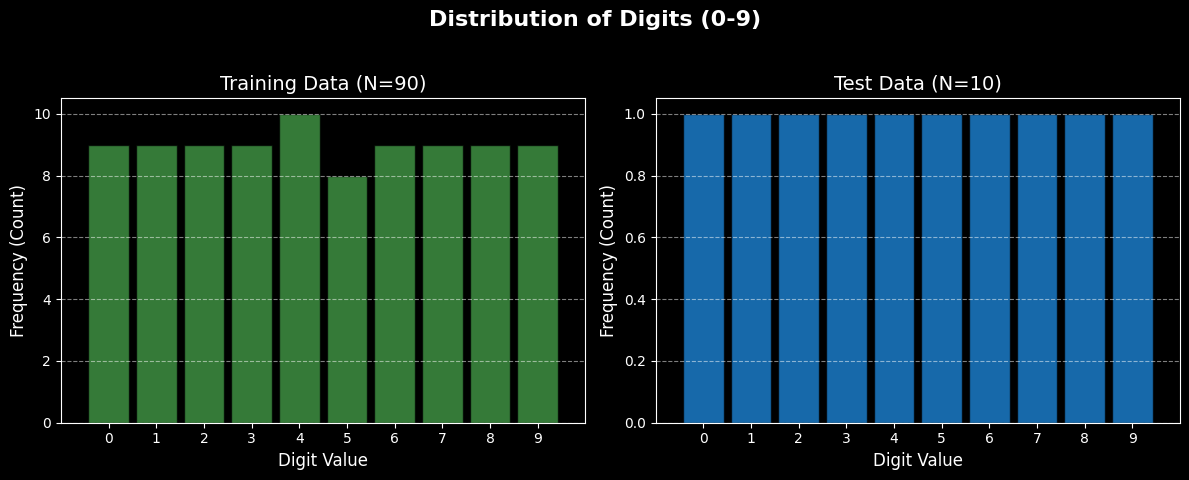

[6. 2. 9. 1. 3. 7. 8. 0. 5. 4.]


In [4]:
np.random.seed(42)

# Use StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=random_seed)

N = len(data)

true_labels = np.array(true_labels)

train_idx, test_idx = next(sss.split(data, true_labels))

x_train, y_train = data[train_idx], true_labels[train_idx]
x_test, y_test = data[test_idx], true_labels[test_idx]

plot_digit_histograms(y_train, y_test)

print(y_test)

## Prepare data for torch

In [5]:
# Move Data to tensors
add_channel = lambda x: x.unsqueeze(1)

x_train_tensor, y_train_tensor = add_channel(torch.from_numpy(x_train)), torch.from_numpy(y_train).long()
x_test_tensor, y_test_tensor = add_channel(torch.from_numpy(x_test)), torch.from_numpy(y_test).long()

# Prepare Dataset
train_set = TensorDataset(x_train_tensor, y_train_tensor)
test_set = TensorDataset(x_test_tensor, y_test_tensor)

# Data loaders
train_batch_size = 16
test_batch_size = len(test_set)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=train_batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=test_batch_size, shuffle=True)

examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

example_data[0].shape

torch.Size([1, 28, 28])

# Loading Model and reasuming training

=========== Epoch 1 ===========
=========== Epoch 2 ===========
=========== Epoch 3 ===========
=========== Epoch 4 ===========
=========== Epoch 5 ===========
=========== Epoch 6 ===========
=========== Epoch 7 ===========
=========== Epoch 8 ===========
=========== Epoch 9 ===========
=========== Epoch 10 ===========
=========== Epoch 11 ===========
=========== Epoch 12 ===========
=========== Epoch 13 ===========
=========== Epoch 14 ===========
=========== Epoch 15 ===========
=========== Epoch 16 ===========
=========== Epoch 17 ===========
=========== Epoch 18 ===========
=========== Epoch 19 ===========
=========== Epoch 20 ===========
=========== Epoch 21 ===========
=========== Epoch 22 ===========
=========== Epoch 23 ===========
=========== Epoch 24 ===========
=========== Epoch 25 ===========
=========== Epoch 26 ===========
=========== Epoch 27 ===========
=========== Epoch 28 ===========
=========== Epoch 29 ===========
=========== Epoch 30 ===========
=========== Epoch 3

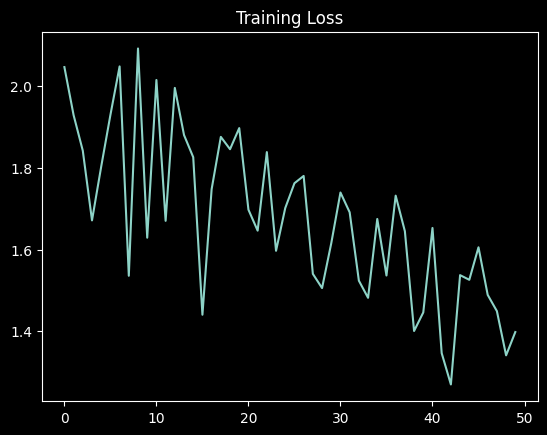

In [6]:
from Model import MyModel

#Hyperparameters
n_epochs = 50
learning_rate = 0.1e-3

# Use GPU acceleration if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
PARAMS_PATH = path.join("trained_models", "model.pth")
model = MyModel().to(device)
model.load_state_dict(torch.load(PARAMS_PATH, map_location=device))

# Freeze convolutional layers
for param in model.conv1.parameters():
    param.requires_grad = False
for param in model.conv2.parameters():
    param.requires_grad = False

# Update only the unfrozen layers
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

criterion = nn.NLLLoss()

train_losses = []

for epoch in range(n_epochs):
    model.train()
    print(f"=========== Epoch {epoch + 1} ===========")
    epoch_loss = []
    for batch_idx, (data, target) in enumerate(train_loader):
        # Transfer data to GPU
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)

        loss = criterion(output, target)
        epoch_loss.append(loss.item())

        loss.backward()
        optimizer.step()

    # Calculate average loss for the entire epoch
    avg_loss = sum(epoch_loss) / len(epoch_loss)
    train_losses.append(avg_loss)

plt.plot(np.arange(n_epochs), train_losses)
plt.title("Training Loss")
plt.show()


# Model Testing


In [7]:
correct = 0

model.eval()

# Disable gradient calculation
with torch.no_grad():
    for (data, target) in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        y_hat = output.data.max(1, keepdim=True)[1]
        correct += y_hat.eq(target.data.view_as(y_hat)).sum()

accuracy = correct / len(test_set)

print(f"{accuracy=}")

accuracy=tensor(0.7000, device='cuda:0')


# Saving a model


In [8]:
torch.save(model.state_dict(), "trained_models/model_fine_tuned.pth")